In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split,Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import  confusion_matrix
from torch.utils.data.sampler import WeightedRandomSampler
from torchsummary import summary
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10


In [2]:
transform=transforms.Compose([
    transforms.Resize((224,224)),    
    transforms.ToTensor() 
])

In [3]:
cifar10_train = CIFAR10(root='./data', train=True, download=True, transform=transform)
cifar10_test = CIFAR10(root='./data', train=False, download=True, transform=transform)

Files already downloaded and verified
Files already downloaded and verified


In [4]:
model_algo="alexnet"

In [5]:
import sys

# 添加自定义模块的目录到模块搜索路径
sys.path.append('/home/pcdm/Desktop')

# 现在可以导入你的自定义模块
from MJPytorch import *

In [6]:
images=CifarDataset(cifar10_train,decision_mode=False)
generator = torch.Generator()
generator.manual_seed(125)

size = len(images)
valid_size = int(0.1 * size)
test_size=int(0.7*size)
train_size = int(size - test_size-valid_size)

trainset, validset,test_set = random_split(images, (train_size, valid_size,test_size), generator=generator)

In [7]:
valid_size

5000

In [8]:
train_size

10000

In [9]:
# create data loaders
batch_size =32 # larger numbers lead to CUDA running out of memory
train_dl = DataLoader(trainset,shuffle=True, batch_size=batch_size)
valid_dl = DataLoader(validset,shuffle=True, batch_size=batch_size)
criterion = nn.CrossEntropyLoss()

/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=1.3974570728302003,train_accu=0.5556
Epoch=0,valid_loss=1.4325281995773316,valid_accu=0.5414
0
Epoch=1,train_loss=1.2369075870513917,train_accu=0.595
Epoch=1,valid_loss=1.2827897171020508,valid_accu=0.576
0
Epoch=2,train_loss=1.1557890176773071,train_accu=0.6144
Epoch=2,valid_loss=1.2120319444656371,valid_accu=0.5916
0
Epoch=3,train_loss=1.100920729637146,train_accu=0.6341
Epoch=3,valid_loss=1.1618754600524903,valid_accu=0.6064
0
Epoch=4,train_loss=1.0646546219825745,train_accu=0.6455
Epoch=4,valid_loss=1.1362739601135254,valid_accu=0.6112
0
Epoch=5,train_loss=1.0311233549118042,train_accu=0.6557
Epoch=5,valid_loss=1.1018797325134277,valid_accu=0.63
0
Epoch=6,train_loss=1.0139857501983642,train_accu=0.656
Epoch=6,valid_loss=1.0880955528259277,valid_accu=0.6274
Epoch=7,train_loss=0.9946555448532104,train_accu=0.6647
Epoch=7,valid_loss=1.0743210043907165,valid_accu=0.6332
0
Epoch=8,train_loss=0.9785343612670898,train_accu=0.6664
Epoch=8,valid_loss=1.0607580080032348,va

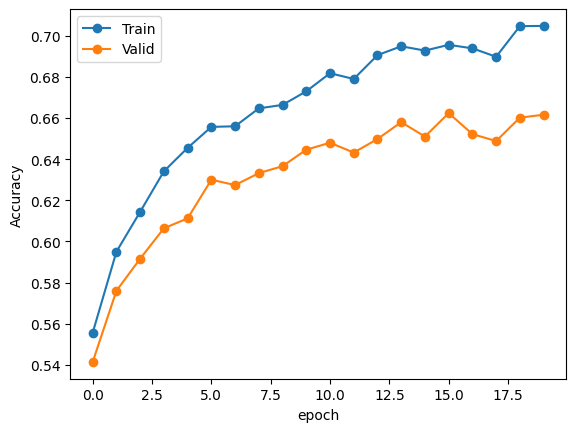

In [10]:
model_0=model_train(model_algo,train_dl,valid_dl,"0",70)
# model_0 = torch.load(f'model_{model_algo}_0_19.pth')

In [11]:
def sample_loss(data_dl,epochs):
    with torch.no_grad():
        for epoch in range(epochs):
            for data, target,idx in data_dl:
                model=torch.load(f'model_{model_algo}_0_{epoch}.pth')
                data,target=data.to(device),target.to(device)  #將data、target放到gpu上
                out= model(data)
                for i,out,t in zip(idx,out,target):    
                    data_dl.dataset.dataset.loss[i]=train_dl.dataset.dataset.loss[i]+calculate_wmse(epoch,epochs,out,t)

In [12]:
sample_loss(train_dl,15)

In [13]:
sample_loss(valid_dl,15)

In [14]:
summary(model_0,(3,299,299))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 74, 74]          23,296
              ReLU-2           [-1, 64, 74, 74]               0
         MaxPool2d-3           [-1, 64, 36, 36]               0
            Conv2d-4          [-1, 192, 36, 36]         307,392
              ReLU-5          [-1, 192, 36, 36]               0
         MaxPool2d-6          [-1, 192, 17, 17]               0
            Conv2d-7          [-1, 384, 17, 17]         663,936
              ReLU-8          [-1, 384, 17, 17]               0
            Conv2d-9          [-1, 256, 17, 17]         884,992
             ReLU-10          [-1, 256, 17, 17]               0
           Conv2d-11          [-1, 256, 17, 17]         590,080
             ReLU-12          [-1, 256, 17, 17]               0
        MaxPool2d-13            [-1, 256, 8, 8]               0
AdaptiveAvgPool2d-14            [-1, 25

In [15]:
train_loss,train_accu,confusion_matrix_train=evaluate_model(model_0,train_dl,train_size,'0',mode='eval')
train_loss,train_accu

(0.8986796600341797, 0.6956)

In [16]:
valid_loss,valid_accu,confusion_matrix_valid=evaluate_model(model_0,valid_dl,valid_size,'0',mode='eval')
valid_loss,valid_accu

(0.9997766036987304, 0.6624)

In [17]:
each_accu=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)
each_accu

airplane      0.591093
automobile    0.759429
bird          0.499499
cat           0.500000
deer          0.720266
dog           0.681407
frog          0.776342
horse         0.745763
ship          0.842786
truck         0.831000
dtype: float64

In [18]:
targetF=[x  for x in each_accu.nsmallest(2).index.map(trainset.dataset.classess)]
targetF

[2, 3]

In [19]:
#將資料切分後建立dataset與dataloader
indexF=[]
indexT=[]
split_mode=('wmse', 0.3)
indexF,indexT=split_data(model_0,train_dl,split_mode)

Fdataset=Subset(images, indexF)
Tdataset=Subset(images, indexT)
Fdl=DataLoader(Fdataset, shuffle=True, batch_size=batch_size)
Tdl=DataLoader(Tdataset, shuffle=True, batch_size=batch_size)
len(indexF),len(indexT)

(7046, 2954)

In [20]:
sum=0
num=0
for i in range(len(train_dl.dataset.dataset.loss)):
    if(train_dl.dataset.dataset.loss[i]!=0):
        sum+=train_dl.dataset.dataset.loss[i]
        num+=1
sum/num

tensor(0.8577, device='cuda:0')

In [21]:
indexF_v=[]
indexT_v=[]

indexF_v,indexT_v=split_data(model_0,valid_dl,split_mode)
len(indexF_v),len(indexT_v)

(3829, 1171)

In [22]:
Fdataset_v=Subset(images, indexF_v)
Tdataset_v=Subset(images, indexT_v)
Fdl_v=DataLoader(Fdataset_v, shuffle=True, batch_size=batch_size)
Tdl_v=DataLoader(Tdataset_v, shuffle=True, batch_size=batch_size)

In [23]:
d_data,d_target=decision_split(train_dl,model_0)
d_v_data,d_v_target=decision_split(valid_dl,model_0)

In [24]:
decisionset=DecisionDataset(d_data,d_target)
decisionset_v=DecisionDataset(d_v_data,d_v_target)

/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=0.5605409640312194,train_accu=0.7227
Epoch=0,valid_loss=0.5198420976638793,valid_accu=0.7704
0
Epoch=1,train_loss=0.5389619058609009,train_accu=0.7376
Epoch=1,valid_loss=0.4978603636264801,valid_accu=0.7792
0
Epoch=2,train_loss=0.5267176735877991,train_accu=0.7448
Epoch=2,valid_loss=0.485031138086319,valid_accu=0.7864
0
Epoch=3,train_loss=0.5182730449676514,train_accu=0.7503
Epoch=3,valid_loss=0.4774741376399994,valid_accu=0.7926
0
Epoch=4,train_loss=0.511839450263977,train_accu=0.7541
Epoch=4,valid_loss=0.47032422742843627,valid_accu=0.7964
0
Epoch=5,train_loss=0.5065433862686157,train_accu=0.7569
Epoch=5,valid_loss=0.464962025976181,valid_accu=0.8006
0
Epoch=6,train_loss=0.5027575539588929,train_accu=0.7577
Epoch=6,valid_loss=0.459740949344635,valid_accu=0.802
0
Epoch=7,train_loss=0.499115691614151,train_accu=0.7598
Epoch=7,valid_loss=0.4556597625732422,valid_accu=0.8036
0
Epoch=8,train_loss=0.4955723665714264,train_accu=0.761
Epoch=8,valid_loss=0.4523694324016571,

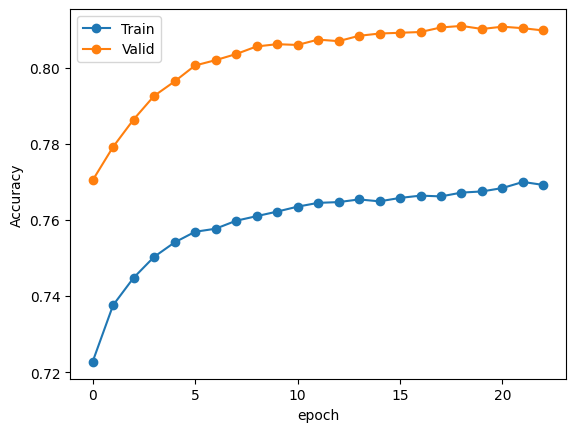

In [25]:
from torchsampler import ImbalancedDatasetSampler
decision_dl = DataLoader(decisionset, batch_size=32)
decision_v_dl = DataLoader(decisionset_v, batch_size=32)
model_decision=model_train(model_algo,decision_dl,decision_v_dl,"decision",70,trainclassnum=len(trainset.dataset.classes))

Epoch=0,train_loss=1.0533228385424243,train_accu=0.8300609343263372
Epoch=0,valid_loss=0.9848995644958685,valid_accu=0.8650725875320239
0
Epoch=1,train_loss=0.6830392241800808,train_accu=0.8947190250507786
Epoch=1,valid_loss=0.6099327250895187,valid_accu=0.9197267292912041
0
Epoch=2,train_loss=0.5124971222538519,train_accu=0.9231550440081245
Epoch=2,valid_loss=0.44314977373962827,valid_accu=0.9444918872758327
0
Epoch=3,train_loss=0.42001794715466817,train_accu=0.9289099526066351
Epoch=3,valid_loss=0.34847115678832025,valid_accu=0.9513236549957301
0
Epoch=4,train_loss=0.34702794764319544,train_accu=0.9485443466486121
Epoch=4,valid_loss=0.28562179882235245,valid_accu=0.964133219470538
0
Epoch=5,train_loss=0.2984294950276028,train_accu=0.9597156398104265
Epoch=5,valid_loss=0.2478896278687566,valid_accu=0.968403074295474
0
Epoch=6,train_loss=0.2604021653179874,train_accu=0.965470548408937
Epoch=6,valid_loss=0.2097533302720442,valid_accu=0.9752348420153715
0
Epoch=7,train_loss=0.23423986523

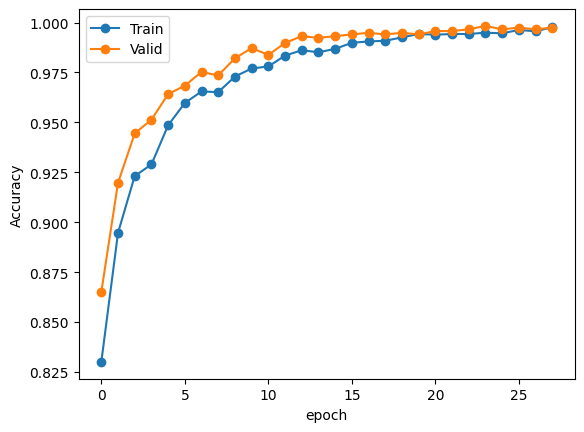

In [26]:
#訓練模型T、F、decision
model_T=model_train(model_algo,Tdl,Tdl_v,"T",70)
# model_T=torch.load(f'model_{model_algo}_T_1.pth')

In [27]:
summary(model_T,(3,299,299))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 74, 74]          23,296
              ReLU-2           [-1, 64, 74, 74]               0
         MaxPool2d-3           [-1, 64, 36, 36]               0
            Conv2d-4          [-1, 192, 36, 36]         307,392
              ReLU-5          [-1, 192, 36, 36]               0
         MaxPool2d-6          [-1, 192, 17, 17]               0
            Conv2d-7          [-1, 384, 17, 17]         663,936
              ReLU-8          [-1, 384, 17, 17]               0
            Conv2d-9          [-1, 256, 17, 17]         884,992
             ReLU-10          [-1, 256, 17, 17]               0
           Conv2d-11          [-1, 256, 17, 17]         590,080
             ReLU-12          [-1, 256, 17, 17]               0
        MaxPool2d-13            [-1, 256, 8, 8]               0
AdaptiveAvgPool2d-14            [-1, 25

Epoch=0,train_loss=1.7513415673020682,train_accu=0.36119784274765826
Epoch=0,valid_loss=1.7601209923753418,valid_accu=0.3546617915904936
0
Epoch=1,train_loss=1.615575285280018,train_accu=0.42038035764973036
Epoch=1,valid_loss=1.6283778290612856,valid_accu=0.4136850352572473
0
Epoch=2,train_loss=1.5426615155491001,train_accu=0.4430882770366165
Epoch=2,valid_loss=1.559993536486642,valid_accu=0.4288325933664142
0
Epoch=3,train_loss=1.485409449116601,train_accu=0.4717570252625603
Epoch=3,valid_loss=1.5079768979228736,valid_accu=0.46461217027944635
0
Epoch=4,train_loss=1.4439130278767898,train_accu=0.4893556627873971
Epoch=4,valid_loss=1.4719839193827802,valid_accu=0.47009663097414467
0
Epoch=5,train_loss=1.410781436876042,train_accu=0.5083735452739143
Epoch=5,valid_loss=1.4356926301964645,valid_accu=0.4949072864977801
0
Epoch=6,train_loss=1.39033758802709,train_accu=0.5083735452739143
Epoch=6,valid_loss=1.4203221271790858,valid_accu=0.4936014625228519
Epoch=7,train_loss=1.3589182443453647,

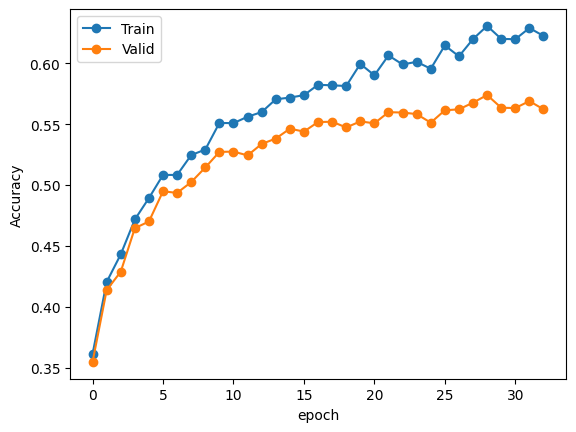

In [28]:
model_F=model_train(model_algo,Fdl,Fdl_v,"F",70)
#model_F=torch.load(f'model_{model_algo}_F_0.pth')

In [29]:
decision_loss,decision_accu,confusion_matrix_decision_train=evaluate_model(model_decision,decision_dl,len(decisionset),'decision',mode='eval')
confusion_matrix_decision_train= confusion_matrix_decision_train.rename(columns={"0":"False","1":"True"}, index={"0":"False","1":"True"})
decision_loss,decision_accu

(0.47613649773597716, 0.7672)

In [30]:
decision_valid_loss,decision_valid_accu,confusion_matrix_decision_valid=evaluate_model(model_decision,decision_v_dl,len(decisionset_v),'decision',mode='eval')
confusion_matrix_decision_valid= confusion_matrix_decision_valid.rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})
decision_valid_loss,decision_valid_accu

(0.431073087644577, 0.811)

In [31]:
T_loss,T_accu,confusion_matrix_T_train=evaluate_model(model_T,Tdl,len(Tdataset),'T',mode='eval')
T_loss,T_accu

(0.06946364281725545, 0.9949221394719026)

In [32]:
F_loss,F_accu,confusion_matrix_F_train=evaluate_model(model_F,Fdl,len(Fdataset),'F',mode='eval')
F_loss,F_accu

(1.1369745968892566, 0.6308543854669316)

In [33]:
T_valid_loss,T_valid_accu,confusion_matrix_T_valid=evaluate_model(model_T,Tdl_v,len(Tdataset_v),'T',mode='eval')
T_valid_loss,T_valid_accu

(0.059383542338158714, 0.9982920580700256)

In [34]:
F_valid_loss,F_valid_accu,confusion_matrix_F_valid=evaluate_model(model_F,Fdl_v,len(Fdataset_v),'F',mode='eval')
F_valid_loss,F_valid_accu

(1.2287436065863118, 0.5740402193784278)

In [35]:
total_train_loss_d,total_train_accu_d,confusion_matrix_total_train,sum=total_model_evaluate_notdecision(train_dl,train_size,model_0,model_T,model_F)
total_train_loss_d,total_train_accu_d,sum

(0.8216326414108276, 0.7384, 7046)

In [36]:
total_valid_loss_d,total_valid_accu_d,confusion_matrix_total_valid_d,sum=total_model_evaluate_notdecision(valid_dl,valid_size,model_0,model_T,model_F)
total_valid_loss_d,total_valid_accu_d,sum

(0.9548785179138184, 0.6734, 3829)

In [37]:
#全部模型裝在一起的表現
def total_model_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    sum_F=0
    sum_T=0
    with torch.no_grad():
        for data,target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)
            out_growth = model_0(data)

            softmax=torch.softmax(out_growth, dim=1)

            out=model_decision(data)
            _, y_pred_tag = torch.max(out, dim = 1)


            for pred,d,t in zip(y_pred_tag,data,target):

                if(pred==0):
                    outputs.append(model_F(d.unsqueeze(0)))
                    sum_F+=1
                else:
                    outputs.append(model_T(d.unsqueeze(0)))
                    sum_T+=1

            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)


            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())

            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    idx2class = {v: k for k, v in data_dl.dataset.dataset.classes}
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total,sum_F,sum_T

In [38]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_train_loss,total_train_accu,sum_F,sum_T

(0.916846007347107, 0.7272, 8746, 1254)

In [39]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_valid_loss,total_valid_accu,sum_F,sum_T

(1.0216656986236572, 0.6706, 4396, 604)

In [40]:
train_losses=[train_loss,decision_loss,T_loss,F_loss,total_train_loss,total_train_loss_d]
train_accuracies=[train_accu,decision_accu,T_accu,F_accu,total_train_accu,total_train_accu_d]
valid_losses=[valid_loss,decision_loss,T_valid_loss,F_valid_loss,total_valid_loss,total_valid_loss_d]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu,F_valid_accu,total_valid_accu,total_valid_accu_d]

In [41]:
model_algos=['Model_0','Model_Decision',"Model_T","Model_F","Total_Model",'Total_Model_without_decision']
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
df

,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.898680,0.695600,0.999777,0.662400
1,Model_Decision,0.476136,0.767200,0.476136,0.811000
2,Model_T,0.069464,0.994922,0.059384,0.998292
3,Model_F,1.136975,0.630854,1.228744,0.574040
4,Total_Model,0.916846,0.727200,1.021666,0.670600
5,Total_Model_without_decision,0.821633,0.738400,0.954879,0.673400


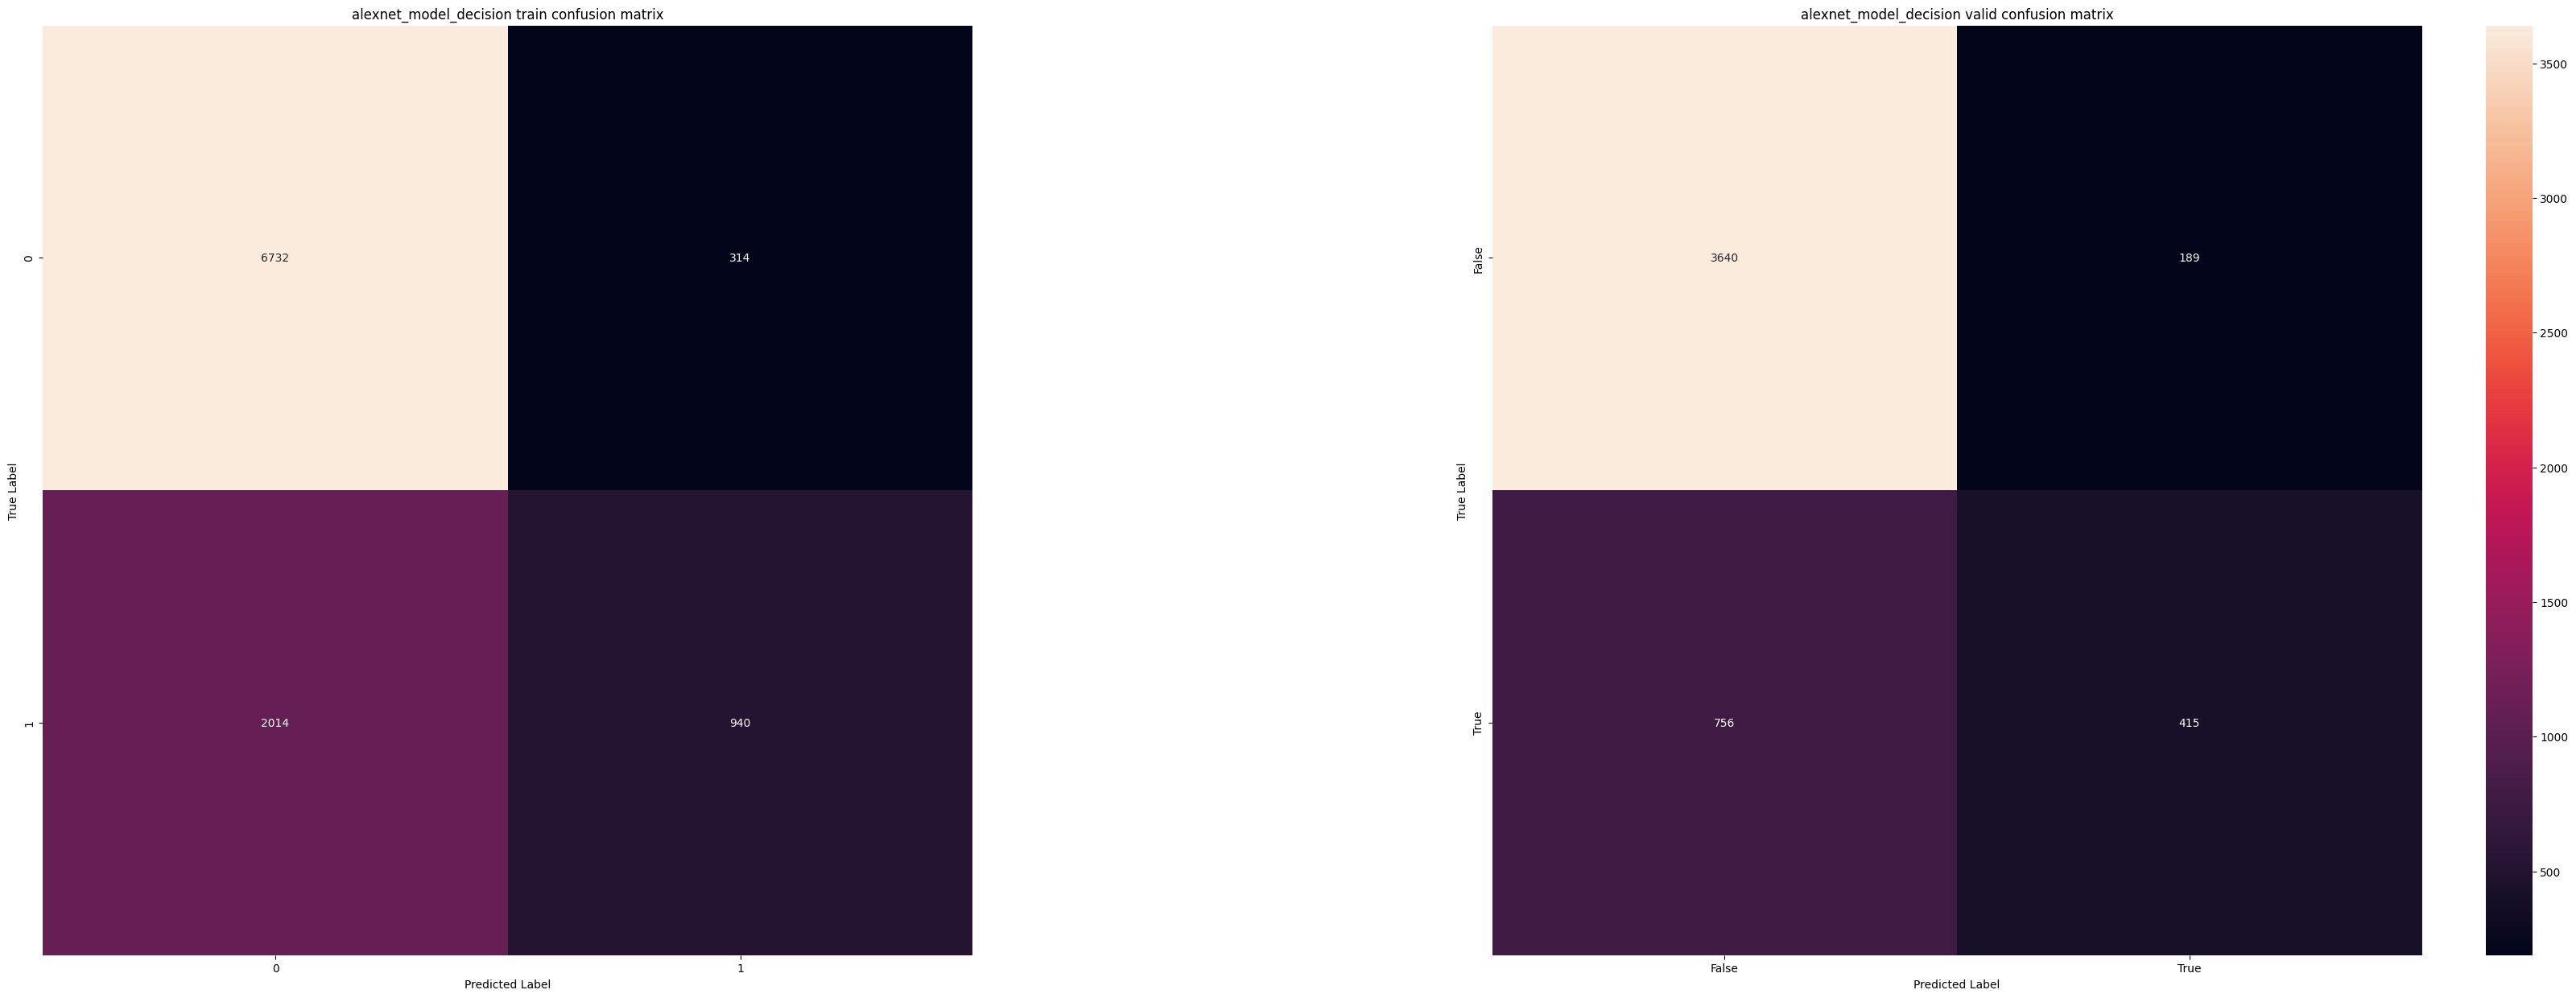

In [42]:
plot_confusion_matrix(confusion_matrix_decision_train,confusion_matrix_decision_valid,"model_decision",model_algo)

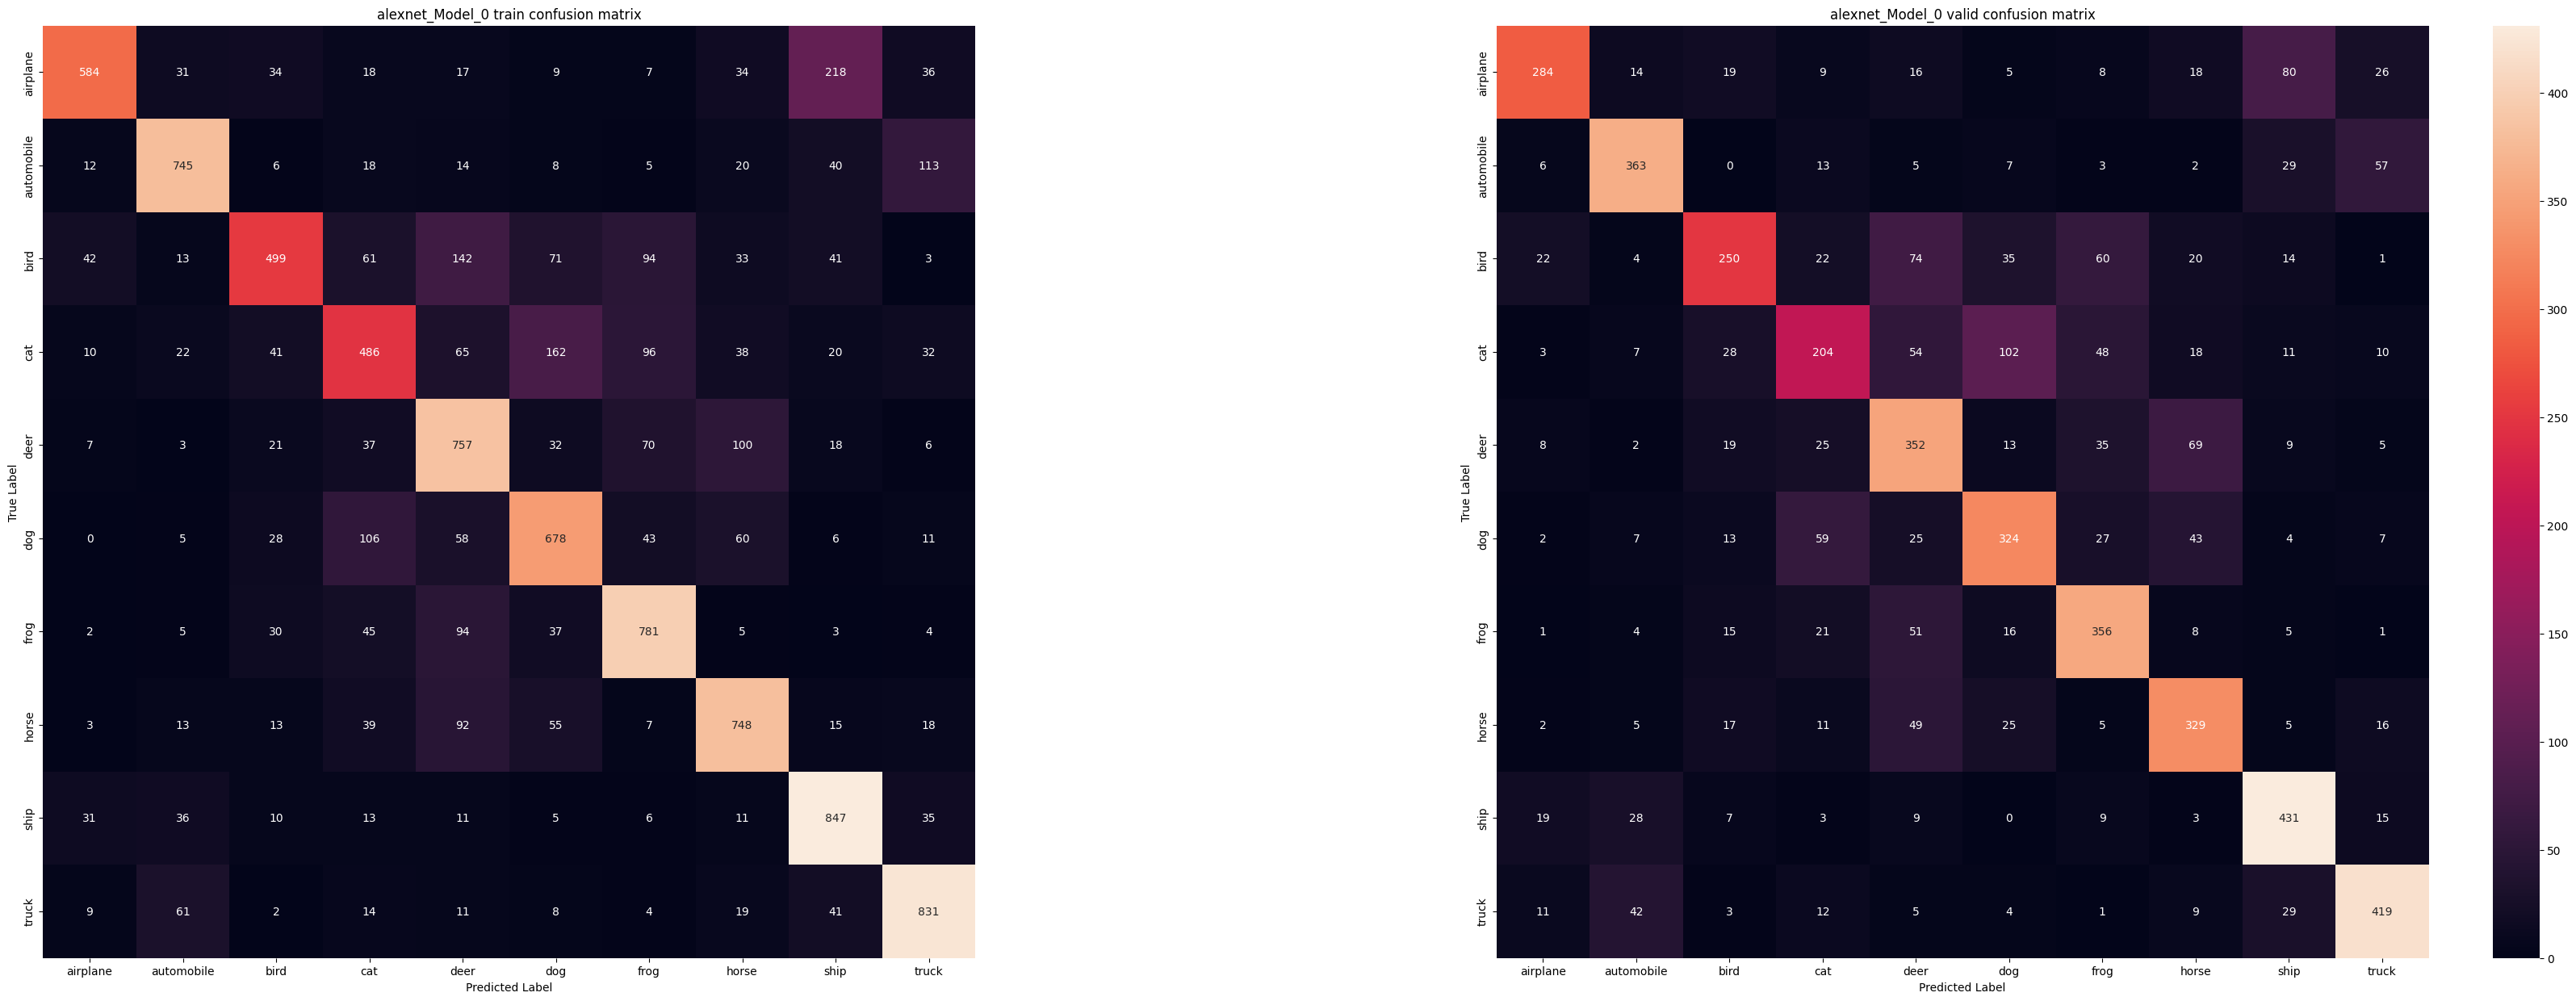

In [43]:
plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,"Model_0",model_algo)

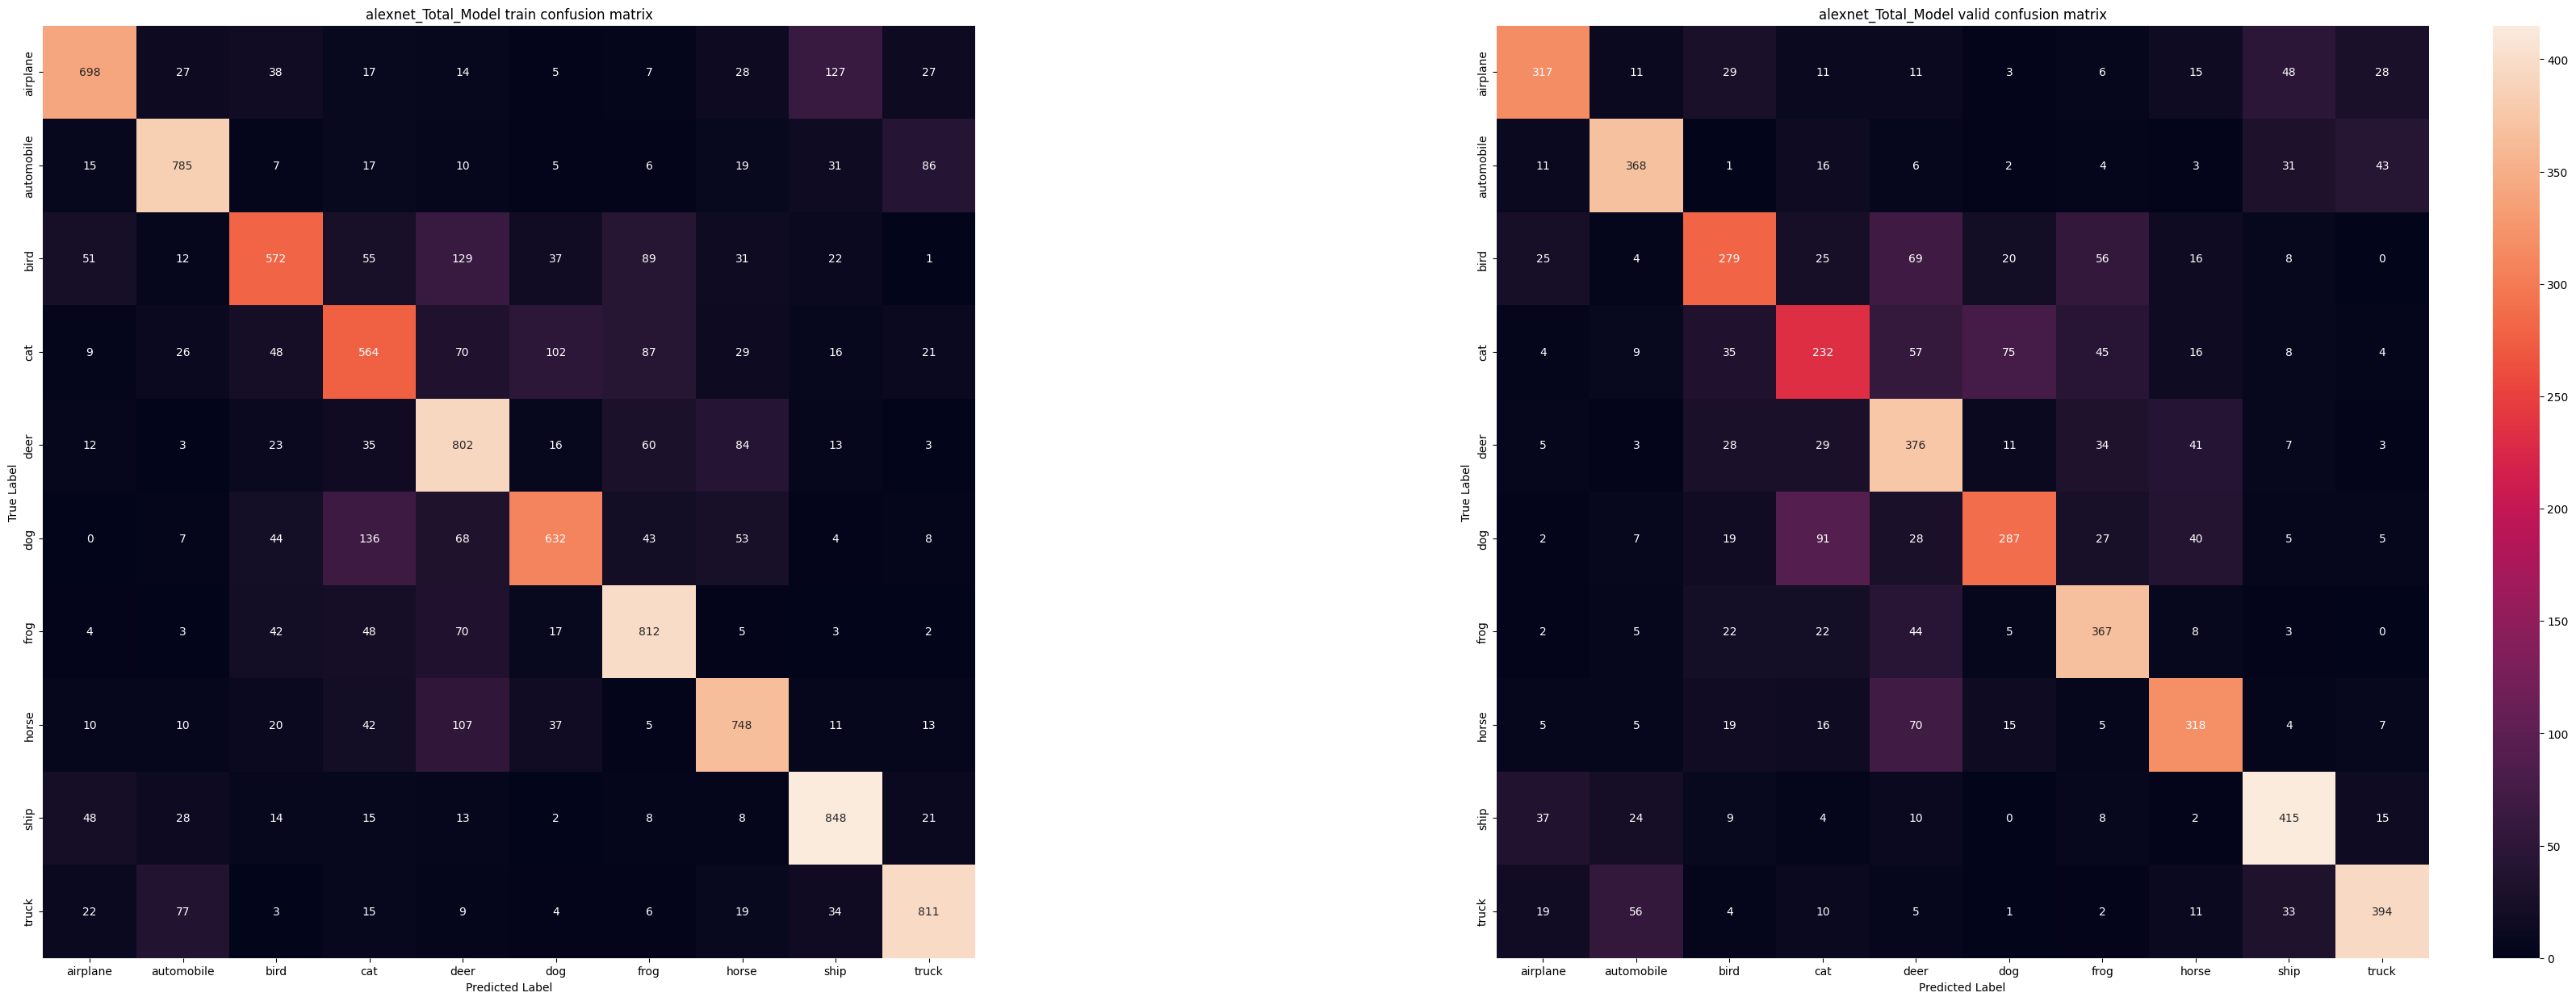

In [44]:
plot_confusion_matrix(confusion_matrix_total_train,confusion_matrix_total_valid,"Total_Model",model_algo)

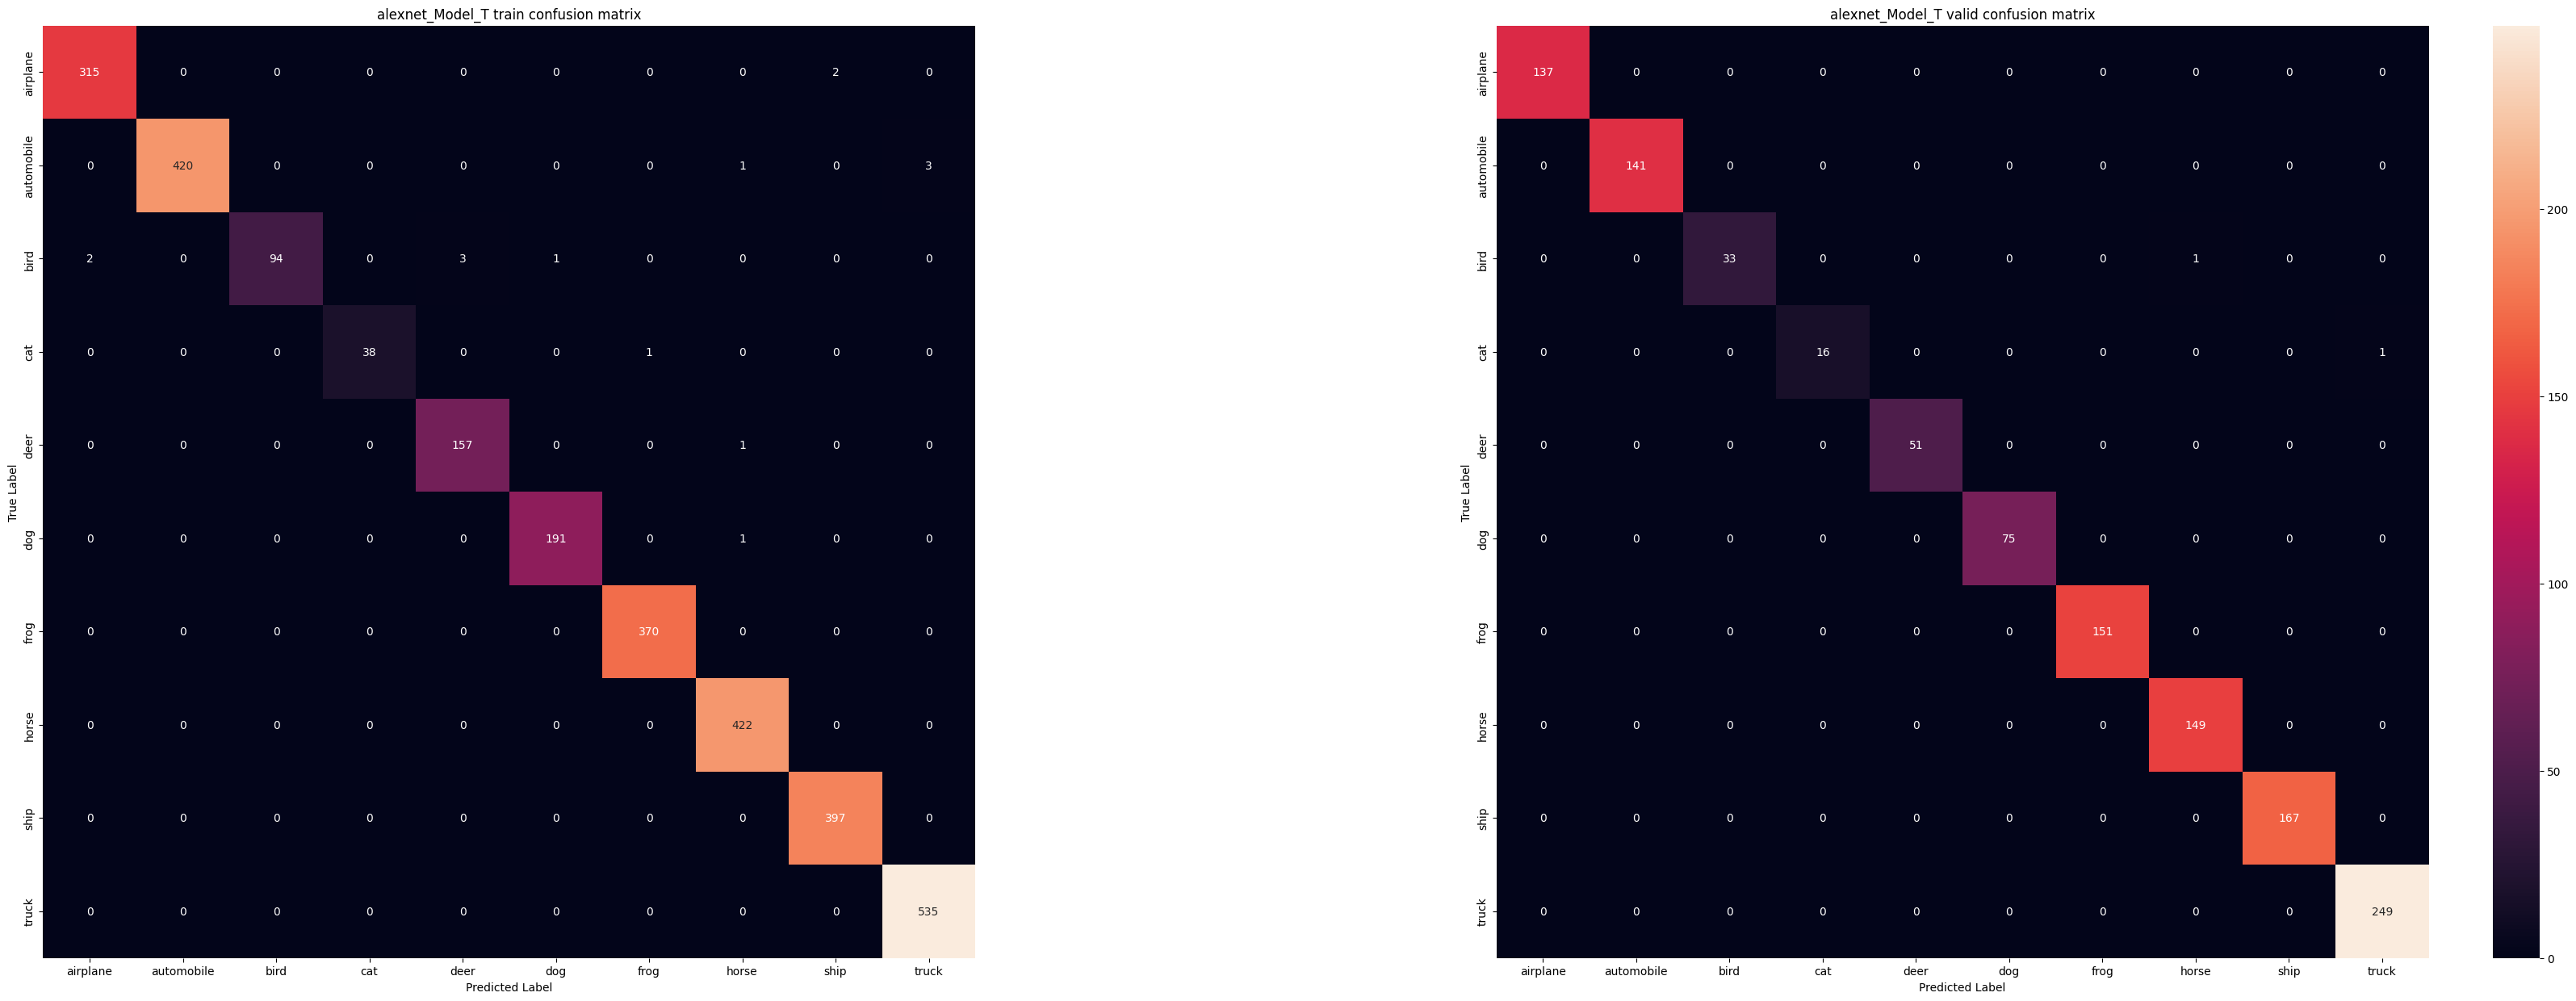

In [45]:
plot_confusion_matrix(confusion_matrix_T_train,confusion_matrix_T_valid,"Model_T",model_algo)

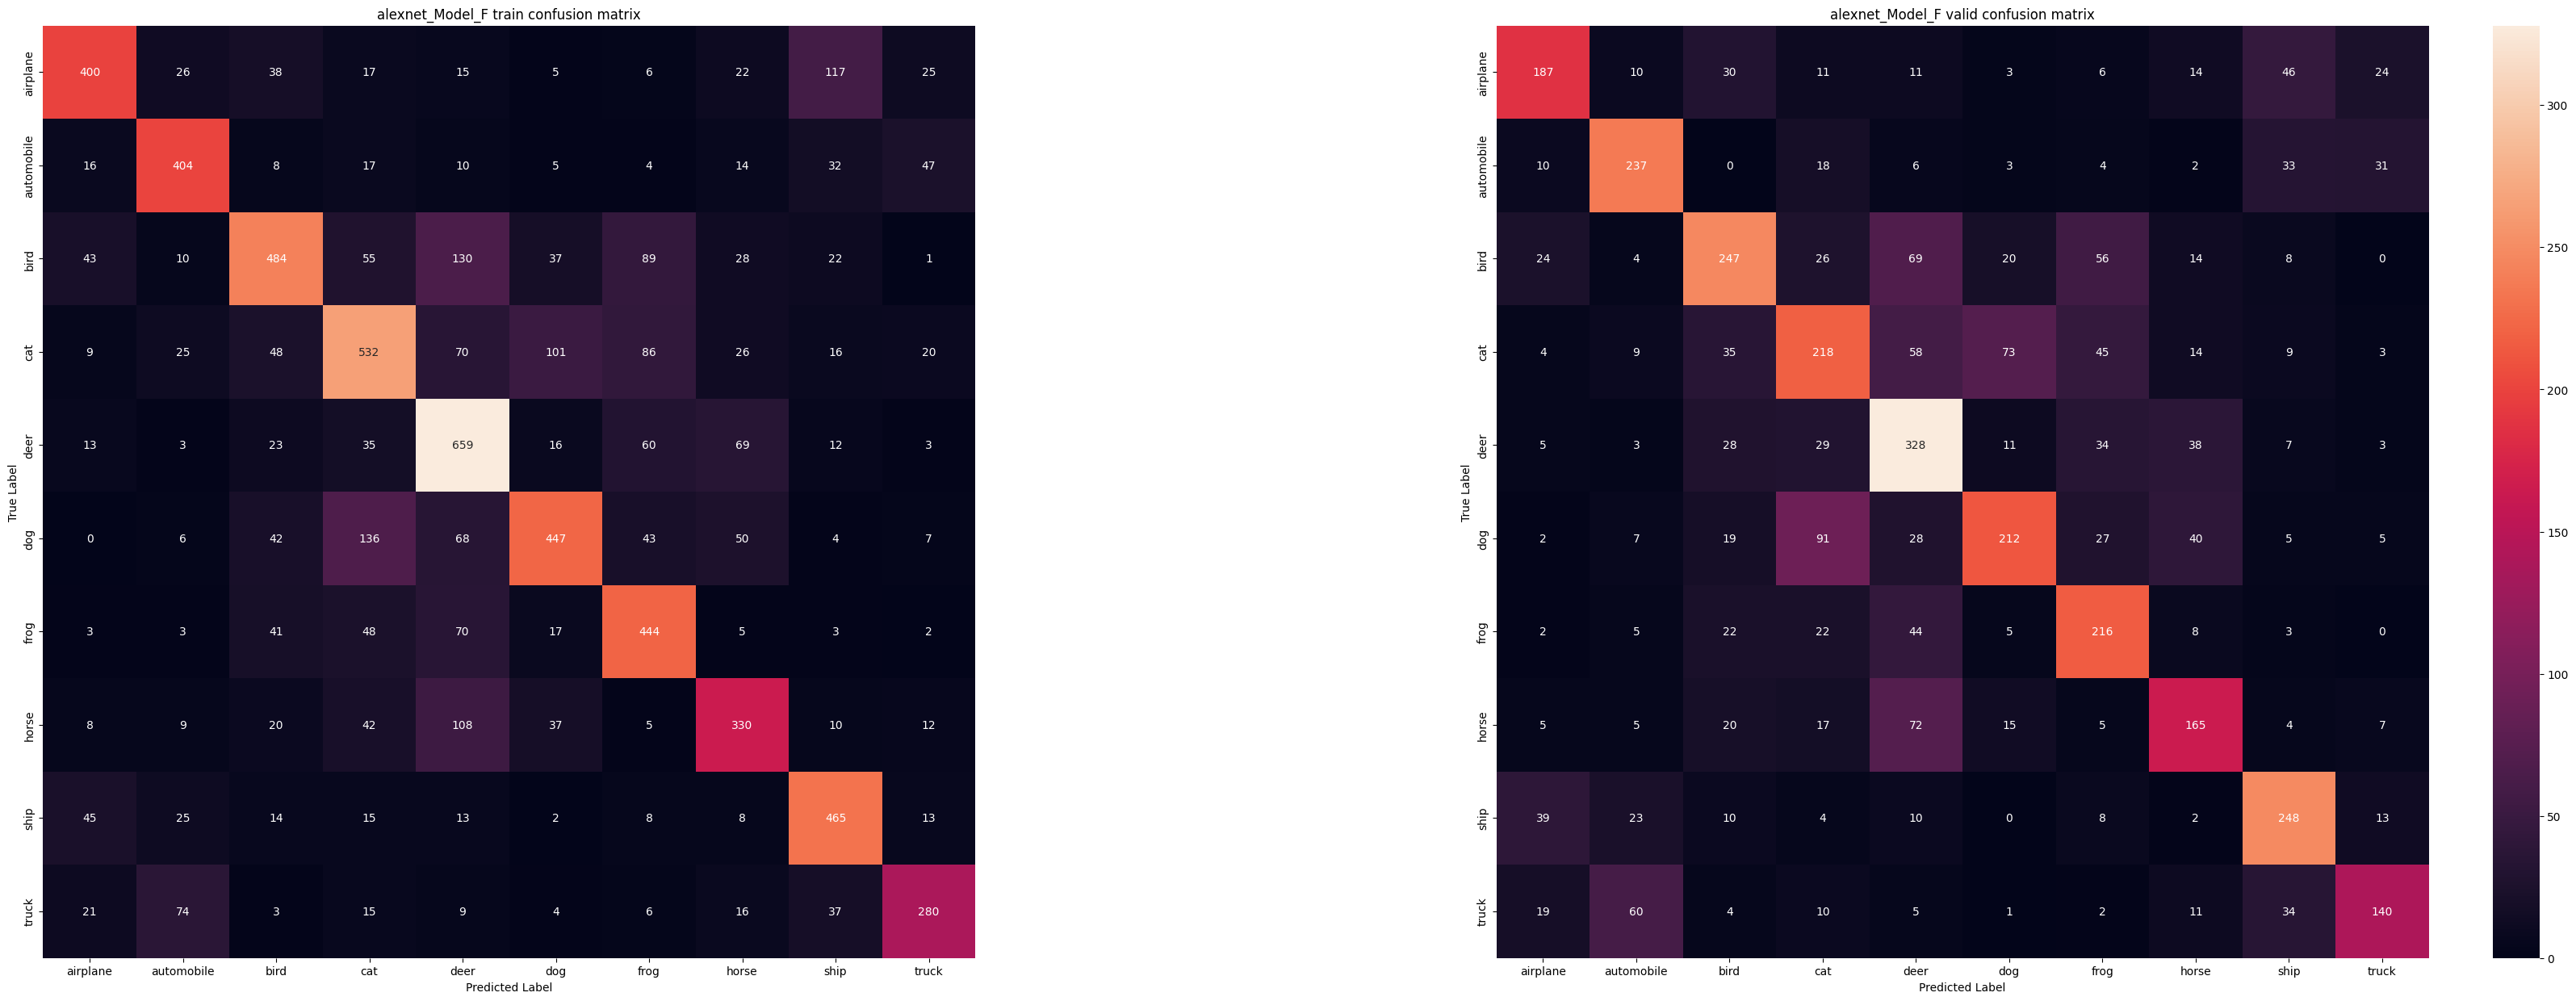

In [46]:
plot_confusion_matrix(confusion_matrix_F_train,confusion_matrix_F_valid,"Model_F",model_algo)

In [49]:
#全部模型裝在一起的表現
def show_model_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    results = []
    
    with torch.no_grad():
        for data,target,idx in data_dl:
   
            data,target=data.to(device),target.to(device) 
            
            for d,t,idx in zip(data,target,idx):
                
                pred_F=torch.max(model_F(d.unsqueeze(0)), dim = 1).indices.item()
                pred_T=torch.max(model_T(d.unsqueeze(0)), dim = 1).indices.item()
                pred_0=torch.max(model_0(d.unsqueeze(0)), dim = 1).indices.item()
                pred_decision=torch.max(model_decision(d.unsqueeze(0)), dim = 1).indices.item()

                    # Record results in a dictionary
                result_dict = {
                    'Index': idx.item(),
                    'Target': t.item(),
                    'Pred_F': pred_F,
                    'Pred_T': pred_T,
                    'Pred_0': pred_0,
                    'Match_F': pred_F == t.item(),
                    'Match_T': pred_T == t.item(),
                    'Match_0': pred_0 == t.item(),
                    'Pred_decision': pred_decision,
                }

                # Append result dictionary to the results list
                results.append(result_dict)

    # Create a DataFrame from the results list
    df_results = pd.DataFrame(results)
    return  df_results

In [50]:
df_results=show_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
df_results

,Index,Target,Pred_F,Pred_T,Pred_0,Match_F,Match_T,Match_0,Pred_decision
0,10255,3,8,8,8,False,False,False,0
1,46903,5,5,5,5,True,True,True,0
2,29896,5,4,4,4,False,False,False,0
3,41040,0,4,4,4,False,False,False,0
4,42241,0,0,0,0,True,True,True,0
...,...,...,...,...,...,...,...,...,...
9995,43554,3,3,3,3,True,True,True,0
9996,7073,6,6,6,6,True,True,True,0
9997,19895,3,0,0,0,False,False,False,0
9998,22235,5,5,3,5,True,False,True,0


In [51]:
df_results=show_model_evaluate(valid_dl,train_size,model_0,model_T,model_F,model_decision)
df_results

,Index,Target,Pred_F,Pred_T,Pred_0,Match_F,Match_T,Match_0,Pred_decision
0,36515,6,6,6,6,True,True,True,0
1,16067,6,6,6,6,True,True,True,0
2,36206,5,5,5,5,True,True,True,0
3,47788,3,2,5,2,False,False,False,0
4,11594,9,9,9,9,True,True,True,0
...,...,...,...,...,...,...,...,...,...
4995,44067,0,2,8,2,False,False,False,0
4996,17307,4,3,3,3,False,False,False,0
4997,30560,1,1,1,1,True,True,True,0
4998,43111,6,6,6,6,True,True,True,0
